# Neural Network (PyTorch)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Carregamento e Exploração dos Dados

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/hepg2.csv')
print(f'Dataset: {df.shape[0]} samples, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}\n')
df.describe().round(2)

Dataset: 216 samples, 6 columns
Columns: ['INDEX', 'ESPÉCIE/LINHAGEM', '% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']



,INDEX,% DMSO,TREHALOSE,% SFB,VIABILIDADE
count,216.00,216.00,216.00,216.00,216.00
mean,108.50,20.74,16.94,58.98,44.33
std,62.50,27.95,26.82,30.56,36.87
min,1.00,0.00,0.00,0.00,0.00
25%,54.75,2.00,0.00,40.00,0.00
50%,108.50,5.00,0.00,70.00,54.44
75%,162.25,30.00,30.00,81.25,76.78
max,216.00,100.00,100.00,100.00,97.33


In [3]:
# Check for linear dependency between variables
# SFB = 100 - DMSO - TREHALOSE (in most cases)
# Therefore, SFB is linearly dependent on DMSO and TREHALOSE.
# Including it as a feature would introduce multicollinearity without adding new information.
df['SUM'] = df['% DMSO'] + df['TREHALOSE'] + df['% SFB']
print('Sum of DMSO + TREHALOSE + SFB:')
print(df['SUM'].value_counts())
df.drop('SUM', axis=1, inplace=True)

Sum of DMSO + TREHALOSE + SFB:
SUM
100.0    208
10.0       8
Name: count, dtype: int64


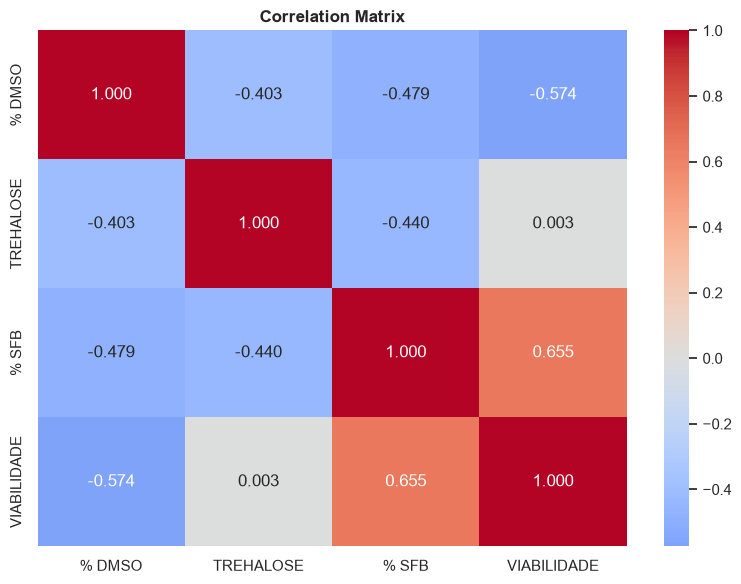

In [4]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f',
    ax=ax
)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('validation_images/nn_correlacao.png', dpi=300)
plt.show()

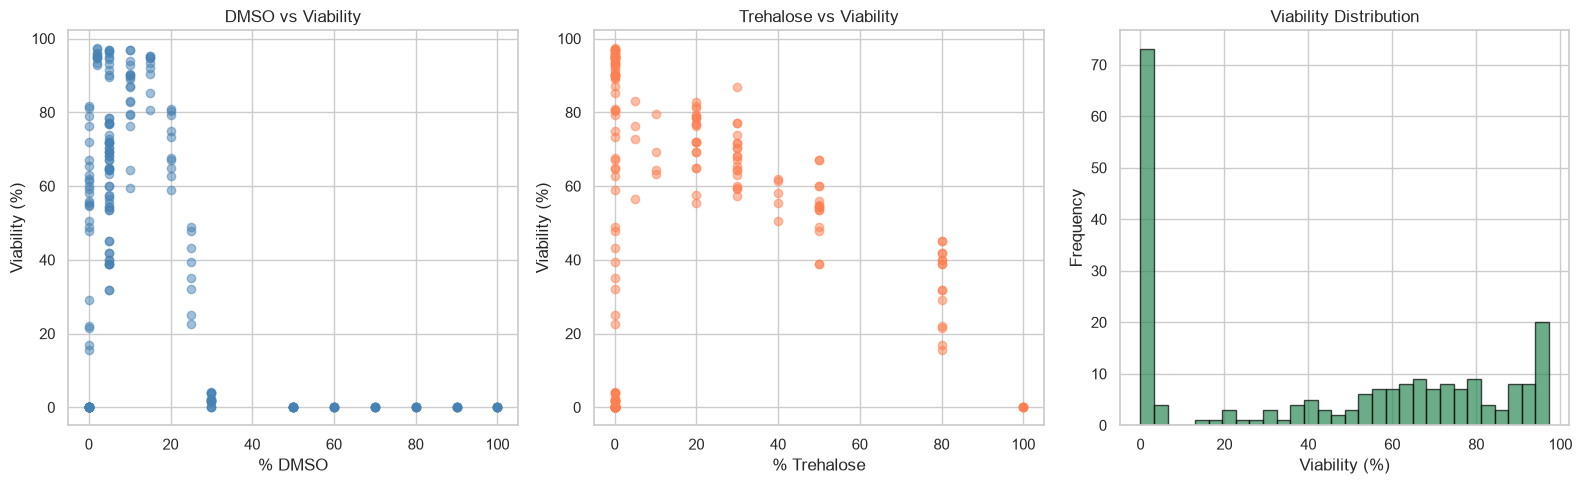

In [5]:
# Viability distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['% DMSO'], df['VIABILIDADE'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('% DMSO')
axes[0].set_ylabel('Viability (%)')
axes[0].set_title('DMSO vs Viability')

axes[1].scatter(df['TREHALOSE'], df['VIABILIDADE'], alpha=0.5, c='coral')
axes[1].set_xlabel('% Trehalose')
axes[1].set_ylabel('Viability (%)')
axes[1].set_title('Trehalose vs Viability')

axes[2].hist(df['VIABILIDADE'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Viability (%)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Viability Distribution')

plt.tight_layout()
plt.savefig('validation_images/nn_distribuicao.png', dpi=300)
plt.show()

## Feature Importance

In [6]:
# Original features
X_raw = df[['% DMSO', 'TREHALOSE']].values
y_all = df['VIABILIDADE'].values
# Feature importance using Random Forest
rf_temp = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)
rf_temp.fit(X_raw, y_all)
print('Feature Importance:')
for name, imp in zip(['% DMSO', 'TREHALOSE'], rf_temp.feature_importances_):
    print(f'  {name}: {imp:.4f}')

Feature Importance:
  % DMSO: 0.7662
  TREHALOSE: 0.2338


Original features: 2 -> Polynomial features: 5
Names: ['DMSO', 'TREHALOSE', 'DMSO^2', 'DMSO TREHALOSE', 'TREHALOSE^2']

Feature Importance (with polynomial terms):
  DMSO^2              : 0.4119
  DMSO                : 0.3541
  TREHALOSE           : 0.1096
  TREHALOSE^2         : 0.1007
  DMSO TREHALOSE      : 0.0236


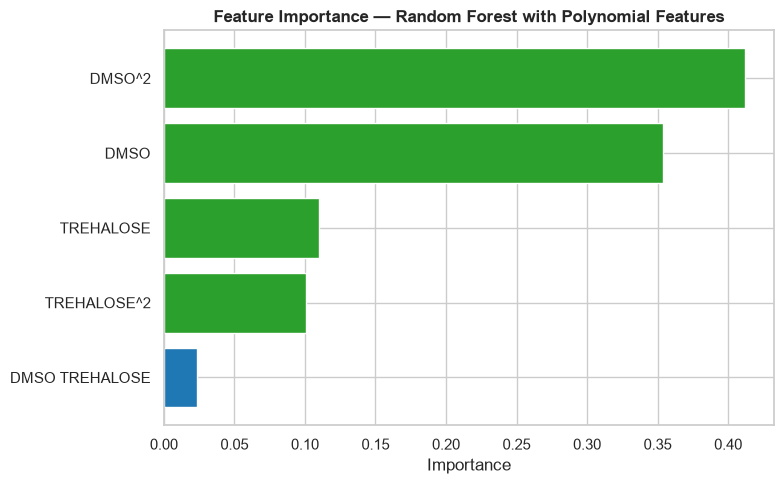

In [7]:
# Feature Engineering: polynomial terms of degree 2
# Captures: DMSO², TREHALOSE², DMSO × TREHALOSE
poly_explorer = PolynomialFeatures(degree=2, include_bias=False)
X_poly_explorer = poly_explorer.fit_transform(X_raw)
feature_names = poly_explorer.get_feature_names_out(['DMSO', 'TREHALOSE'])
print(f'Original features: 2 -> Polynomial features: {X_poly_explorer.shape[1]}')
print(f'Names: {list(feature_names)}\n')
# Feature importance with polynomial features
rf_poly = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)
rf_poly.fit(X_poly_explorer, y_all)
importances = rf_poly.feature_importances_
indices = np.argsort(importances)[::-1]
print('Feature Importance (with polynomial terms):')
for i in indices:
    print(f'  {feature_names[i]:20s}: {importances[i]:.4f}')
# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ca02c' if imp > 0.1 else '#1f77b4'
          for imp in importances[indices]]
ax.barh(range(len(indices)), importances[indices], color=colors)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Importance')
ax.set_title(
    'Feature Importance — Random Forest with Polynomial Features',
    fontweight='bold'
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('validation_images/nn_feature_importance.png', dpi=300)
plt.show()

## Data Preparation

In [8]:
# =============================================================
# Triple split: 60% train / 20% validation / 20% test
# =============================================================
# The VALIDATION set is used for Early Stopping and LR Scheduler.
# The TEST set is held out and used ONLY ONCE for final evaluation.
# This prevents data leakage.
# =============================================================

# Step 1: split into 80% (train+validation) and 20% (test)
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw,
    y_all,
    test_size=0.2,
    random_state=SEED
)

# Step 2: split the 80% into 60% training and 20% validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    test_size=0.25,
    random_state=SEED
)

# Feature engineering (fit ONLY on training data)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_raw)
X_val_poly = poly.transform(X_val_raw)
X_test_poly = poly.transform(X_test_raw)

# Standardization (fit ONLY on training data)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)
X_test_scaled = scaler.transform(X_test_poly)

print(f'Train:      {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features')
print(f'Validation: {X_val_scaled.shape[0]} samples')
print(f'Test:       {X_test_scaled.shape[0]} samples')
print(f'Total:      {X_train_scaled.shape[0] + X_val_scaled.shape[0] + X_test_scaled.shape[0]} samples')

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)

X_val_t = torch.FloatTensor(X_val_scaled).to(DEVICE)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

X_test_t = torch.FloatTensor(X_test_scaled).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

Train:      129 samples, 5 features
Validation: 43 samples
Test:       44 samples
Total:      216 samples


## Neural Network Architecture

* **Input layer**: 5 neurons (DMSO, Trehalose, DMSO², DMSO×Trehalose, Trehalose²)
* **3 hidden layers**: 128 → 64 → 32 neurons
* **Batch Normalization** in each layer (stabilizes training)
* **Dropout** (20%) for regularization and overfitting prevention
* **ReLU activation** in the hidden layers
* **Output layer**: 1 neuron (cell viability %)

In [9]:
class HepatoCryoNN(nn.Module):
    def __init__(self, input_dim=5, dropout_rate=0.2):
        super(HepatoCryoNN, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: input -> 128
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2: 128 -> 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3: 64 -> 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output: 32 -> 1
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# Instantiate model
model = HepatoCryoNN(
    input_dim=X_train_scaled.shape[1]
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}\n')

print(model)

Total parameters: 11,585
Trainable parameters: 11,585

HepatoCryoNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training

In [10]:
# Training Hyperparameters
EPOCHS = 2000
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4       # L2 regularization
PATIENCE = 100            # Early stopping: stop if no improvement for 100 epochs

# Loss function and optimizer
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning Rate Scheduler (monitors VALIDATION loss)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=30,
    min_lr=1e-6
)

In [11]:
# TRAINING LOOP
# Early Stopping and LR Scheduler monitor VALIDATION loss (not test loss).

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(EPOCHS):

    # --- TRAINING ---
    model.train()

    epoch_train_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        n_batches += 1

    if n_batches == 0:
        continue

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    # --- VALIDATION EVALUATION ---
    model.eval()

    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, y_val_t).item()

    val_losses.append(val_loss)

    # Learning Rate Scheduler (based on validation, NOT test)
    scheduler.step(val_loss)

    # Early Stopping (based on validation, NOT test)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), 'best_nn_model.pth')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}')
        break

    # Log every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(
            f'Epoch {epoch + 1:4d}/{EPOCHS} | '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | '
            f'LR: {optimizer.param_groups[0]["lr"]:.6f}'
        )

print(
    f'\nTraining completed. '
    f'Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})'
)

Epoch  100/2000 | Train Loss: 1774.2392 | Val Loss: 1862.6860 | LR: 0.001000
Epoch  200/2000 | Train Loss: 518.2718 | Val Loss: 188.8349 | LR: 0.001000
Epoch  300/2000 | Train Loss: 269.9345 | Val Loss: 86.4151 | LR: 0.001000

Early stopping at epoch 375. Best epoch: 275

Training completed. Best epoch: 275 (Val Loss: 66.0211)


In [12]:
# Load the best saved model
model.load_state_dict(
    torch.load('best_nn_model.pth', weights_only=True)
)
model.eval()
print('Best model loaded.')

Best model loaded.


## 6. Test Set Evaluation

In [13]:
# Final predictions (the test set is touched for the FIRST and ONLY time here)
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).cpu().numpy().flatten()
    y_pred_test = model(X_test_t).cpu().numpy().flatten()

# Metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('PERFORMANCE METRICS — NEURAL NETWORK (PyTorch)\n')
print(f'Train -> R² = {r2_train:.4f} | RMSE = {rmse_train:.2f}%')
print(f'Test  -> R² = {r2_test:.4f} | RMSE = {rmse_test:.2f}%')

PERFORMANCE METRICS — NEURAL NETWORK (PyTorch)

Train -> R² = 0.8628 | RMSE = 14.12%
Test  -> R² = 0.9091 | RMSE = 10.64%


## View

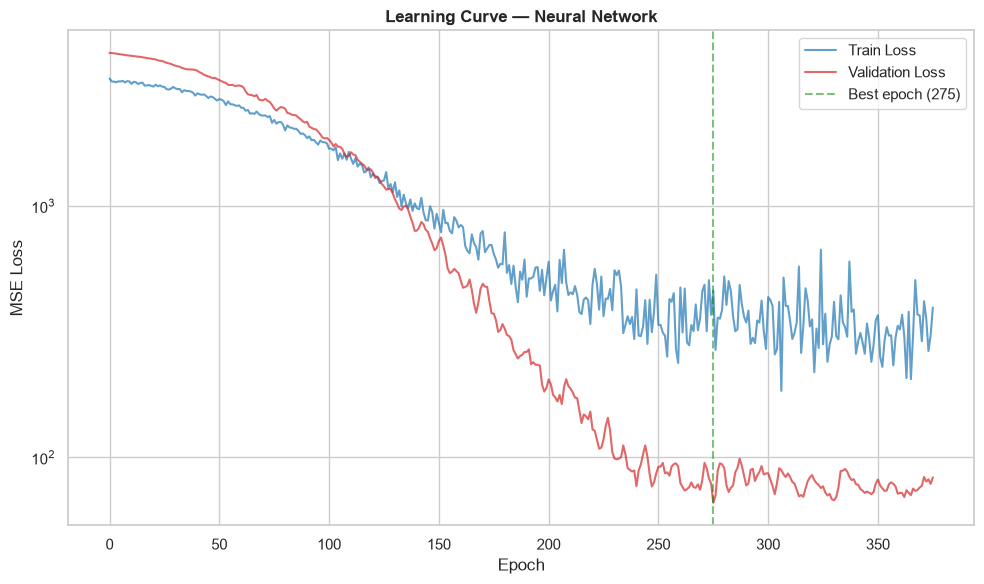

In [14]:
# Loss Curve (Training vs Validation)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train Loss', color='#1f77b4', alpha=0.7)
ax.plot(val_losses, label='Validation Loss', color='#d62728', alpha=0.7)
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Learning Curve — Neural Network', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('validation_images/nn_curva_loss.png', dpi=300)
plt.show()

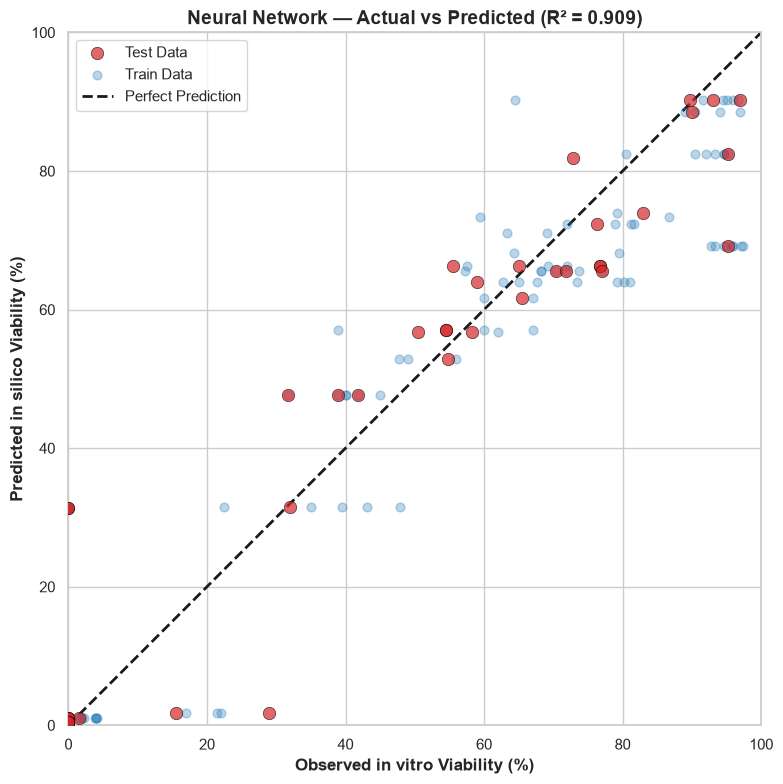

In [21]:
# Plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_test, alpha=0.7, color='#d62728', s=80, 
           edgecolors='black', linewidths=0.5, label='Test Data', zorder=3)
ax.scatter(y_train, y_pred_train, alpha=0.3, color='#1f77b4', s=40, 
           label='Train Data', zorder=2)

lims = [min(y_all.min(), 0), max(y_all.max(), 100)]
ax.plot(lims, lims, 'k--', lw=2, label='Perfect Prediction', zorder=1)

ax.set_xlabel('Observed in vitro Viability (%)', fontweight='bold')
ax.set_ylabel('Predicted in silico Viability (%)', fontweight='bold')
ax.set_title(f'Neural Network — Actual vs Predicted (R² = {r2_test:.3f})', fontweight='bold', fontsize=14)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('validation_images/nn_real_vs_previsto.png', dpi=300)
plt.show()

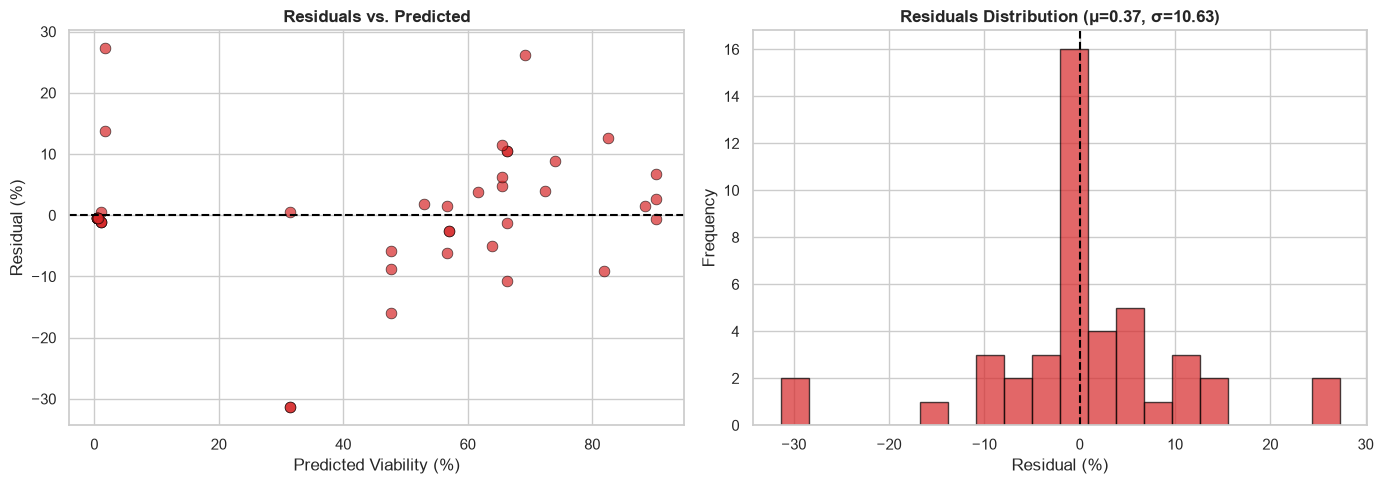

In [16]:
# Residuals Plot
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.7, color='#d62728', s=60, edgecolors='black', linewidths=0.5)
axes[0].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted Viability (%)')
axes[0].set_ylabel('Residual (%)')
axes[0].set_title('Residuals vs. Predicted', fontweight='bold')

# Distribution of Residuals
axes[1].hist(residuals, bins=20, color='#d62728', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution (μ={residuals.mean():.2f}, σ={residuals.std():.2f})', fontweight='bold')

plt.tight_layout()
plt.savefig('validation_images/nn_residuos.png', dpi=300)
plt.show()

## K-Fold Cross-Validation (K=5)

In [17]:
def train_and_evaluate_fold(
    X_train_f,
    y_train_f,
    X_val_f,
    y_val_f,
    input_dim,
    epochs=1500,
    patience=80
):
    """Trains a new neural network for a fold and returns R² and RMSE."""

    # Prepare tensors
    X_tr = torch.FloatTensor(X_train_f).to(DEVICE)
    y_tr = torch.FloatTensor(y_train_f).unsqueeze(1).to(DEVICE)

    X_vl = torch.FloatTensor(X_val_f).to(DEVICE)
    y_vl = torch.FloatTensor(y_val_f).unsqueeze(1).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=32,
        shuffle=True,
        drop_last=True
    )

    # New model for each fold
    fold_model = HepatoCryoNN(input_dim=input_dim).to(DEVICE)

    criterion_f = nn.MSELoss()

    optimizer_f = optim.Adam(
        fold_model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler_f = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_f,
        mode='min',
        factor=0.5,
        patience=25,
        min_lr=1e-6
    )

    best_val_loss = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(epochs):

        fold_model.train()

        for X_b, y_b in loader:
            optimizer_f.zero_grad()

            loss = criterion_f(fold_model(X_b), y_b)

            loss.backward()
            optimizer_f.step()

        fold_model.eval()

        with torch.no_grad():
            val_loss = criterion_f(
                fold_model(X_vl),
                y_vl
            ).item()

        scheduler_f.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            best_state = fold_model.state_dict().copy()
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    # Load best state and evaluate
    fold_model.load_state_dict(best_state)

    fold_model.eval()

    with torch.no_grad():
        y_pred_val = fold_model(X_vl).cpu().numpy().flatten()

    r2 = r2_score(y_val_f, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val_f, y_pred_val))

    return r2, rmse


# ============================================================
# Run K-Fold Cross-Validation on train+validation data
# (excluding the test set)
# ============================================================
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

fold_r2 = []
fold_rmse = []

print('--- K-FOLD CROSS-VALIDATION (K=5) ---\n')

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval_raw)):

    # Fold data
    X_tr_raw_f = X_trainval_raw[train_idx]
    X_vl_raw_f = X_trainval_raw[val_idx]

    y_tr_f = y_trainval[train_idx]
    y_vl_f = y_trainval[val_idx]

    # Feature engineering (fit on fold training data)
    poly_f = PolynomialFeatures(degree=2, include_bias=False)

    X_tr_poly_f = poly_f.fit_transform(X_tr_raw_f)
    X_vl_poly_f = poly_f.transform(X_vl_raw_f)

    # Standardization (fit on fold training data)
    sc_f = StandardScaler()

    X_tr_sc_f = sc_f.fit_transform(X_tr_poly_f)
    X_vl_sc_f = sc_f.transform(X_vl_poly_f)

    r2, rmse = train_and_evaluate_fold(
        X_tr_sc_f,
        y_tr_f,
        X_vl_sc_f,
        y_vl_f,
        input_dim=X_tr_sc_f.shape[1]
    )

    fold_r2.append(r2)
    fold_rmse.append(rmse)

    print(
        f'  Fold {fold + 1}: '
        f'R² = {r2:.4f} | RMSE = {rmse:.2f}%'
    )

print(
    f'\n  MEAN: R² = {np.mean(fold_r2):.4f} '
    f'(+/- {np.std(fold_r2):.4f})'
)

print(
    f'  MEAN: RMSE = {np.mean(fold_rmse):.2f}% '
    f'(+/- {np.std(fold_rmse):.2f}%)'
)

--- K-FOLD CROSS-VALIDATION (K=5) ---

  Fold 1: R² = 0.8872 | RMSE = 10.56%
  Fold 2: R² = 0.7606 | RMSE = 18.68%
  Fold 3: R² = 0.8984 | RMSE = 12.67%
  Fold 4: R² = 0.9331 | RMSE = 9.39%
  Fold 5: R² = 0.8550 | RMSE = 13.92%

  MEAN: R² = 0.8669 (+/- 0.0587)
  MEAN: RMSE = 13.04% (+/- 3.23%)


## Final Comparison: Random Forest vs. Neural Network

In [18]:
# Random Forest trained under the same conditions
# (using only raw features, with 60% training data)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)

rf_model.fit(X_train_raw, y_train)

y_pred_rf = rf_model.predict(X_test_raw)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'Random Forest -> R² = {r2_rf:.4f} | RMSE = {rmse_rf:.2f}%')
print(f'Neural Network -> R² = {r2_test:.4f} | RMSE = {rmse_test:.2f}%')

Random Forest -> R² = 0.9745 | RMSE = 5.63%
Neural Network -> R² = 0.9091 | RMSE = 10.64%


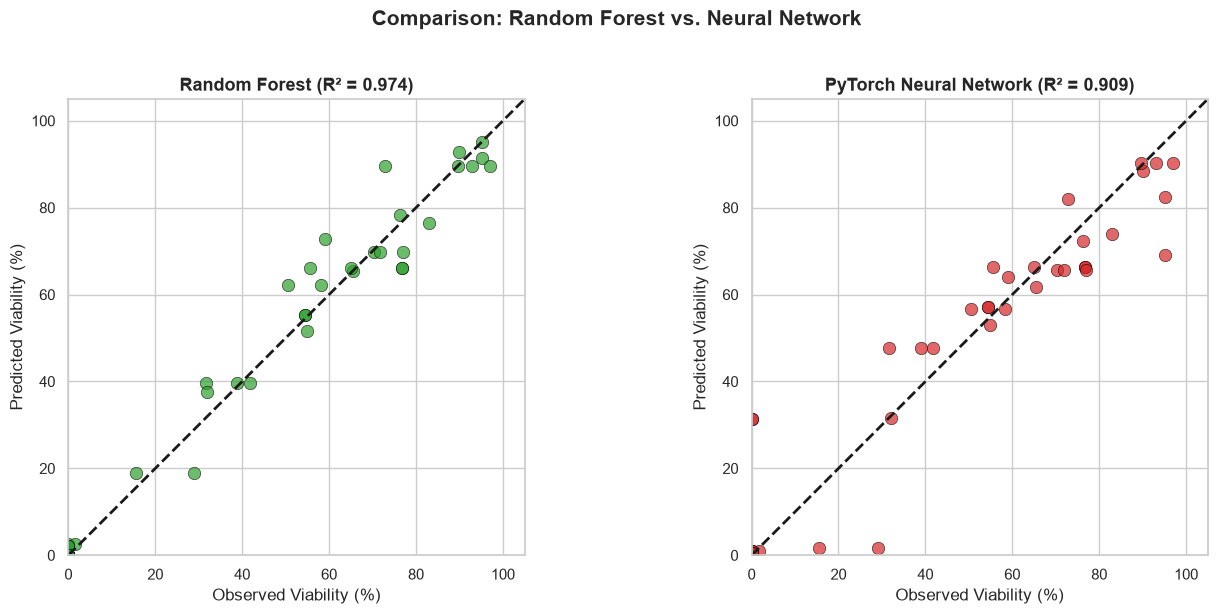

In [19]:
# Comparative plot: side-by-side scatter plots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lims = [0, 105]

# Random Forest
axes[0].scatter(
    y_test,
    y_pred_rf,
    alpha=0.7,
    color='#2ca02c',
    s=80,
    edgecolors='black',
    linewidths=0.5
)
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlabel('Observed Viability (%)')
axes[0].set_ylabel('Predicted Viability (%)')
axes[0].set_title(
    f'Random Forest (R² = {r2_rf:.3f})',
    fontweight='bold',
    fontsize=13
)

axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect('equal')

# Neural Network
axes[1].scatter(
    y_test,
    y_pred_test,
    alpha=0.7,
    color="#d62728",
    s=80,
    edgecolors='black',
    linewidths=0.5
)

axes[1].plot(lims, lims, 'k--', lw=2)
axes[1].set_xlabel('Observed Viability (%)')
axes[1].set_ylabel('Predicted Viability (%)')
axes[1].set_title(
    f'PyTorch Neural Network (R² = {r2_test:.3f})',
    fontweight='bold',
    fontsize=13
)

axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_aspect('equal')

plt.suptitle(
    'Comparison: Random Forest vs. Neural Network',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('validation_images/nn_comparativo_rf_vs_nn.png', dpi=300, bbox_inches='tight')
plt.show()

## Model and Pipeline Export

In [20]:
# Save the complete pipeline
pipeline = {
    'poly': poly,       # PolynomialFeatures (already fitted on training data)
    'scaler': scaler,   # StandardScaler (already fitted on training data)
    'input_dim': X_train_scaled.shape[1],
    'metrics': {
        'r2_test': r2_test,
        'rmse_test': rmse_test,
        'r2_train': r2_train,
        'rmse_train': rmse_train,
        'cv_r2_mean': np.mean(fold_r2),
        'cv_r2_std': np.std(fold_r2),
        'cv_rmse_mean': np.mean(fold_rmse),
        'cv_rmse_std': np.std(fold_rmse),
    }
}

joblib.dump(pipeline, '../nn_pipeline.pkl')
torch.save(model.state_dict(), '../nn_model.pth')

print('Files saved:')
print('  - ../nn_model.pth (neural network weights)')
print('  - ../nn_pipeline.pkl (PolynomialFeatures + StandardScaler + metrics)')
print('  - best_nn_model.pth (best model during training)')
print()

print('Exported metrics:')

for k, v in pipeline['metrics'].items():
    print(f'  {k}: {v:.4f}')

Files saved:
  - ../nn_model.pth (neural network weights)
  - ../nn_pipeline.pkl (PolynomialFeatures + StandardScaler + metrics)
  - best_nn_model.pth (best model during training)

Exported metrics:
  r2_test: 0.9091
  rmse_test: 10.6354
  r2_train: 0.8628
  rmse_train: 14.1243
  cv_r2_mean: 0.8669
  cv_r2_std: 0.0587
  cv_rmse_mean: 13.0418
  cv_rmse_std: 3.2310
